In [1]:
import numpy as np
import matplotlib.pyplot as plt
from gaiamock import gaiamock_var  as gm
from gaiamock import gaiamock_mod  as gmo
from gaiamock import variability_tool as vt
import pandas as pd
path_to_data="/Users/giulianoiorio/Dropbox/Work_Project/RRLgaiamock/paper/data/healpix_scans/healpix_scans"
gm.set_healpyx_table_path(path_to_data)
gmo.set_healpyx_table_path(path_to_data)

RUWE 0.9600541733414627
RUWE 1.6524567768264449


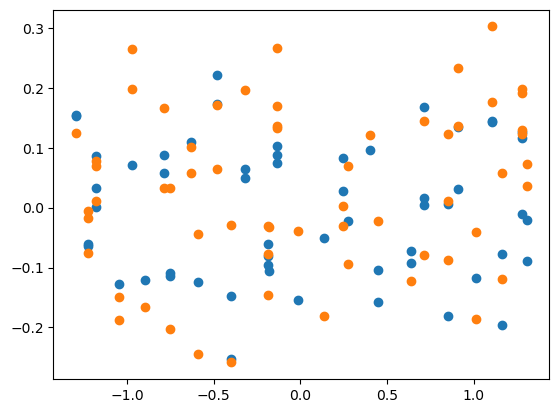

In [10]:
ra=230
dec=35
pmra=0
pmdec=0
parallax=0.2
phot_g_mean_mag=14

#JDB_TCB = t_gaia + 2455197.5

t,psi,plx, Lambda, error = gm.predict_astrometry_single_source(ra=ra,dec=dec,
                                    pmra=pmra,pmdec=pmdec,
                                    parallax=parallax,
                                    data_release="dr3",
                                    phot_g_mean_mag=phot_g_mean_mag
                                   )
print("RUWE",gm.check_ruwe(t_ast_yr=t, psi=psi, plx_factor=plx, ast_obs=Lambda, ast_err=error,binned=False)[0])
plt.scatter(t,Lambda)

varmodel=vt.SimpleSinusoidal(amp=0.3,period=0.27,fchrom=0.3,relative_norm=False)
t,psi,plx, Lambda, error = gm.predict_astrometry_single_source(ra=ra,dec=dec,
                                    pmra=pmra,pmdec=pmdec,
                                    parallax=parallax,
                                    data_release="dr3",
                                    phot_g_mean_mag=phot_g_mean_mag,
                                    variability_tool=varmodel
                                   )
print("RUWE",gm.check_ruwe(t_ast_yr=t, psi=psi, plx_factor=plx, ast_obs=Lambda, ast_err=error,binned=False)[0])
plt.scatter(t,Lambda)

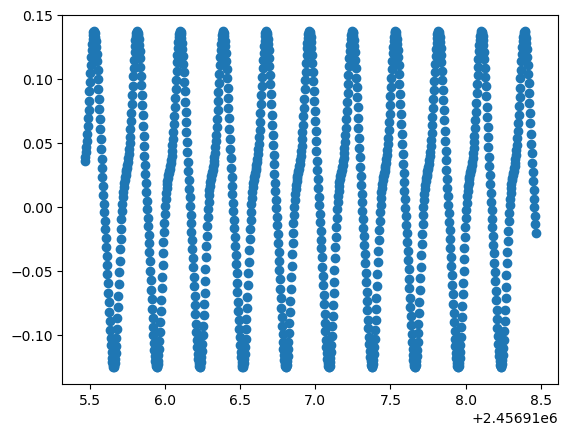

In [6]:
datadf=pd.read_parquet("/Users/giulianoiorio/Dropbox/Work_Project/RRLgaiamock/paper/data/RRL/RL_G3_kine_reduced_wIB21_extramet_cleaned_highmet_wharmonics.parquet")
fr=vt.RRLVariable(datadf.iloc[12],fchrom=0.2)

xx=np.linspace(0,3,int(1000))+fr.LCtemplate_g.reference_time+2455197.5 
#fr.LCtemplate_bp.reference_time
fr(xx)
plt.scatter(xx,fr(xx))
#plt.plot(xx,fr.g_lcurve(xx))
#plt.axhline(fr.LCtemplate_bp.obs_average-fr.LCtemplate_rp.obs_average)
#plt.scatter(xx,fr.LCtemplate_bp.lc(xx))
#plt.axhline(fr.LCtemplate_bp.obs_average)
#plt.scatter(xx,fr.LCtemplate_rp.lc(xx))
#plt.axhline(fr.LCtemplate_rp.obs_average)

RUWE 1.3463384735275596
RUWE 1.3742055386384562


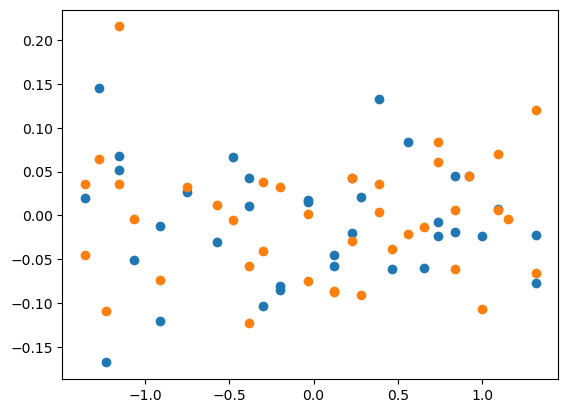

In [11]:
ra=230
dec=60
pmra=0
pmdec=0
parallax=0.05
phot_g_mean_mag=12

t,psi,plx, Lambda, error = gm.predict_astrometry_single_source(ra=ra,dec=dec,
                                    pmra=pmra,pmdec=pmdec,
                                    parallax=parallax,
                                    data_release="dr3",
                                    phot_g_mean_mag=phot_g_mean_mag,
                                   )
print("RUWE",gmo.check_ruwe(t_ast_yr=t, psi=psi, plx_factor=plx, ast_obs=Lambda, ast_err=error,binned=False)[0])
plt.scatter(t,Lambda)


varmodel=vt.RRLVariable(datadf.iloc[59],fchrom=0.3,relative_norm=False)
t,psi,plx, Lambda, error = gm.predict_astrometry_single_source(ra=ra,dec=dec,
                                    pmra=pmra,pmdec=pmdec,
                                    parallax=parallax,
                                    data_release="dr3",
                                    phot_g_mean_mag=phot_g_mean_mag,
                                    variability_tool=varmodel
                                   )
print("RUWE",gm.check_ruwe(t_ast_yr=t, psi=psi, plx_factor=plx, ast_obs=Lambda, ast_err=error,binned=False)[0])
plt.scatter(t,Lambda)

RUWE 0.9271224947925647
RUWE 1.4457122696710203


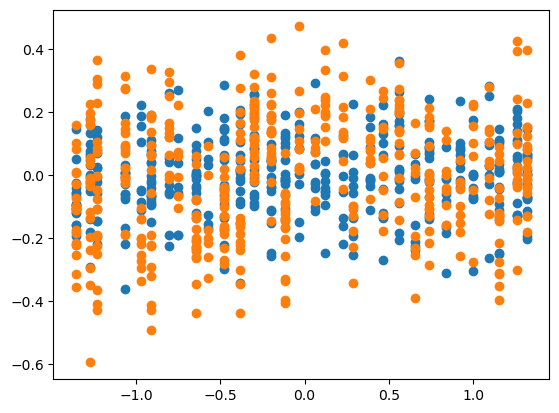

In [12]:
ra=230
dec=60
pmra=0
pmdec=0
parallax=0.05
phot_g_mean_mag=13

t,psi,plx, Lambda, error = gmo.predict_astrometry_single_source(ra=ra,dec=dec,
                                    pmra=pmra,pmdec=pmdec,
                                    parallax=parallax,
                                    data_release="dr3",
                                    phot_g_mean_mag=phot_g_mean_mag,
                                    c_funcs=None
                                   )
print("RUWE",gmo.check_ruwe(t_ast_yr=t, psi=psi, plx_factor=plx, ast_obs=Lambda, ast_err=error,binned=False)[0])
plt.scatter(t,Lambda)


varmodel=vt.RRLVariable(datadf.iloc[20],fchrom=2,relative_norm=False)
t,psi,plx, Lambda, error = gmo.predict_astrometry_single_source(ra=ra,dec=dec,
                                    pmra=pmra,pmdec=pmdec,
                                    parallax=parallax,
                                    data_release="dr3",
                                    phot_g_mean_mag=phot_g_mean_mag,
                                    c_funcs=None,
                                    variability_tool=varmodel
                                   )
print("RUWE",gm.check_ruwe(t_ast_yr=t, psi=psi, plx_factor=plx, ast_obs=Lambda, ast_err=error,binned=False)[0])
plt.scatter(t,Lambda)

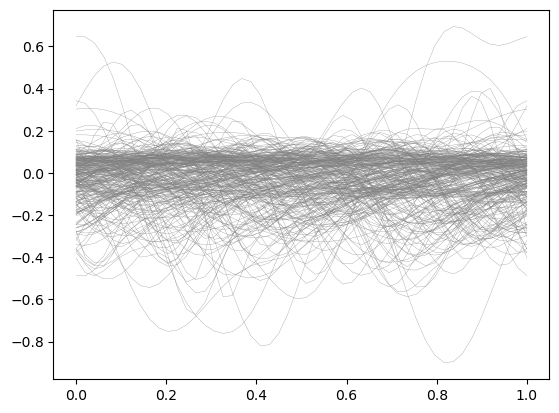

In [30]:
N=len(datadf)

xx=np.linspace(0,1)
for  i in range(N):
    varmodel=vt.RRLVariable(datadf.iloc[i],fchrom=2,relative_norm=False)
    BP=varmodel.LCtemplate_bp.lc(xx,folded=True)
    RP=varmodel.LCtemplate_rp.lc(xx,folded=True)
    plt.plot(xx,(BP-RP)-(varmodel.average_bp-varmodel.average_rp),c="gray",lw=0.2)

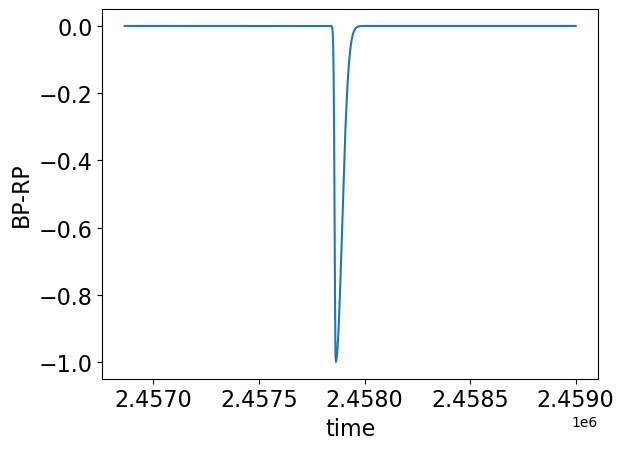

In [17]:
#JBDTCB ≈ 2456863.5 to 2459000.5

cb=vt.ColorBurst(amp=-1,tpeak=2457863.5,dtrise=5,dtdecay=30,fchrom=1)
xx=np.linspace(2456863.5,2459000.5,1000)

plt.xlabel("time",fontsize=16)
plt.ylabel("BP-RP",fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.plot(xx,cb(xx))